## Inputs Iniciais

### Imports

In [2]:
# imports
import os
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from src.training_functions import play_episode
from src.training_functions import play_episode_sequence
from src.market import market
from src.market import extract_close
from src.random_agent import random_agent
from src.momentum_agent import momentum_agent
from src.buy_hold_agent import buy_hold_agent
from src.qlearning_agent import qlearning_agent
from src.plotting_functions import plot_value_evolution

### Download inicial dos dados dos tickers em .csv

In [3]:
# --- Download & save data in the same format expected by market.py (Date + Close) ---
tickers = ["AAPL"]#, "MSFT", "GOOGL", "AMZN"]

data = yf.download(tickers, start="2010-01-01", auto_adjust=False, group_by="column", progress=False)

close = extract_close(data)

os.makedirs("data", exist_ok=True)

for ticker in tickers:
    if ticker not in close.columns:
        # In some edge cases yfinance may return a different naming, so we fail loudly.
        raise KeyError(f"Ticker '{ticker}' not found in Close data columns: {list(close.columns)}")
    single = close[[ticker]].reset_index()
    single.columns = ["Date", "Close"]

    # Match the legacy CSV date format found in the repository: dd-mm-YYYY
    single["Date"] = pd.to_datetime(single["Date"]).dt.strftime("%d-%m-%Y")

    single.to_csv(f"data/{ticker}.csv", index=False)
    

## Definição do ambiente

Definição inicial da variável env. O ambiente é inicializado todas as vezes que se chama a função play_episode.

In [4]:
env = market(tickers, budget=1e4)

## Desafio (Trabalho Final) — *Market RL Agent*

O objetivo é criares um **agente** capaz de interagir com o ambiente `market` (definido em `market.py`), tomando decisões de ação ao longo do tempo com base no estado observado.

> **Importante:** não se foquem demasiado em “ganhar” ao `RandomAgent`. O foco é **aprofundar um conceito da aula**, justificar decisões e mostrar pensamento crítico.  
> **Serás avaliado mais pela interpretação do que pelo melhor resultado.**

---

### Tarefa Principal

Escolhe **apenas UMA** das abordagens abaixo e resolve o problema.

#### Opção A — Monte Carlo (MC)
- Define claramente o que é um **episódio** no ambiente `market`.
- Escolhe MC **First-Visit** ou **Every-Visit**.
- Implementa:
  - política
  - avaliação/controlo (estimativa de \(V(s)\) ou \(Q(s,a)\))
  - mecanismo de exploração
- Discute: **variança**, necessidade de múltiplas amostras, impacto do tempo e escolha das recompensas.

#### Opção B — Temporal Difference (TD) ✅
- Escolhe **TD(0)** / **SARSA** / **Q-Learning**.
- Implementa:
  - tabela de \(Q(s,a)\) (ou uma aproximação simples, se justificares)
  - exploração (ε-greedy)
  - learning rate (α) e discount (γ)
- Discute: **bootstrapping**, estabilidade, exploração vs exploração, convergência.

---

### Criatividade (Obrigatório)
Experimenta **pelo menos 2** escolhas “criativas”, por exemplo:
- **state abstraction** (ex.: discretização de retornos, bins, features simples)
- **reward shaping** (e justificar impactos)
- **multi-start** (várias corridas e comparar)
- **ε schedule** (fixo vs decaimento)
- **γ/α schedules** (constante vs adaptativo)
- mistura de métodos (ex.: MC para inicializar, TD para refinar)
- diferentes representações para o estado (mais/menos informação)

---

### Experiências Obrigatórias (para qualquer opção)
1. Corre o teu agente **várias vezes** (pelo menos **5** runs), com **seeds diferentes**. ✅
2. Varia parâmetros relevantes (pelo menos **2 configurações** por agente). 
3. Guarda e mostra o **histórico do valor/custo** ao longo do treino (learning curve). ✅
4. Faz pelo menos uma comparação com um baseline simples (ex.: `RandomAgent` e/ou `MomentumAgent`). ✅

**Gráficos obrigatórios:**
- Evolução do **retorno/valor do episódio** ao longo do treino (por episódio ou por iterações). ✅
- Idealmente: inclui média móvel (ex.: janela 20) + dispersão (min/max ou std) entre runs. ✅

**Outputs recomendados:**
- Gráficos: retorno por episódio (com várias seeds) ✅
- Uma tabela pequena: configuração → melhor retorno → média/variância ✅
- Comentário crítico: “o que funcionou / o que não funcionou / porquê”

---

### O que entregar

Um **Jupyter Notebook** contendo:
- Código (bem organizado e comentado)
- Experiências (várias runs, vários parâmetros)
- Interpretação crítica (texto)

Um **video** com uma breve apresentação do trabalho (~5 minutos) em que correm o trabalho e comentam as escolhas feitas  
(sugestão: OBS Studio para gravação do ecrã).

**Enviar o notebook e video da apresentação para (ivoacnogueira@gmail.com ou ivo.nogueira@isag.pt) até dia 15 de Março de 2026**.

---

### Regras

- Trabalho individual
- Código original
- Permitido: `numpy`, `pandas`, `matplotlib` (e bibliotecas standard do Python)
- Não usar bibliotecas RL/otimização prontas (ex.: `stable-baselines`, `gymnasium` trainers, `scipy.optimize`, etc.)
- Se usares uma aproximação de função (ex.: regressão simples), justifica claramente e mantém a implementação “manual” e pedagógica.

# Resolução - Opção B - Temporal Difference (Q-Learning)

## Visualizar evolução do preço para contexto

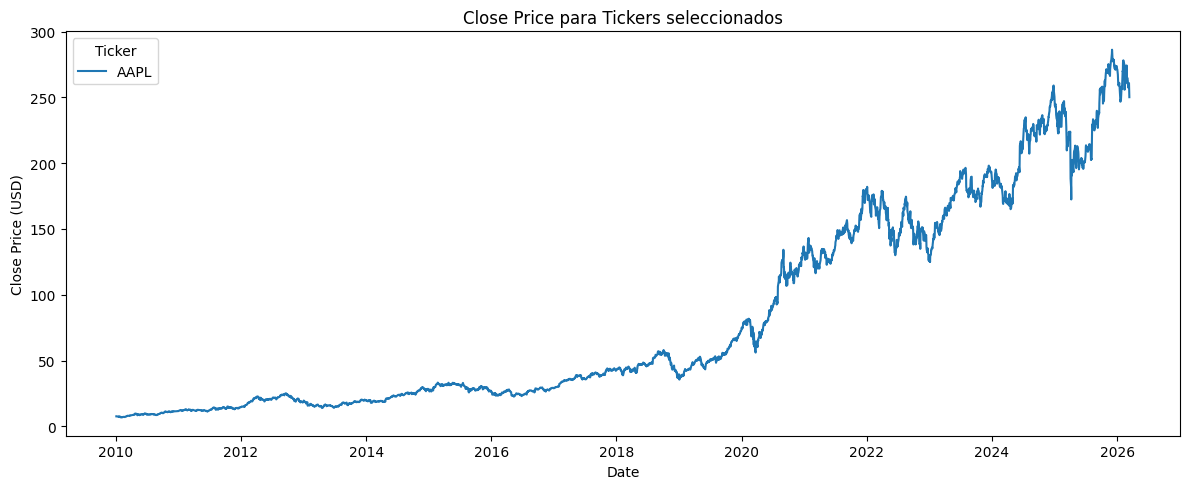

In [5]:
type(close)
close.head()
close[tickers].plot(
    figsize=(12, 5), 
    title="Close Price para Tickers seleccionados")
plt.xlabel('Date')
plt.xticks(rotation=0, ha='center')
plt.ylabel('Close Price (USD)')
plt.tight_layout()
plt.show()


## Baseline - Random Agent 5 x 50 episódios

In [6]:
n_runs = 5
n_episodes_per_run = 50 

compilation_random_agent = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = random_agent(num_actions=len(env.index_actions))
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_random_agent.append(run_values)


## Baseline - Momentum Agent 5 x 50 episódios

Window = 3

In [7]:
n_runs = 5
n_episodes_per_run = 50 

compilation_momentum_agent_w3 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = momentum_agent(num_actions = len(env.index_actions), num_companies = env.total_companies)
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_momentum_agent_w3.append(run_values)

Window = 20

In [8]:
n_runs = 5
n_episodes_per_run = 50 

compilation_momentum_agent_w20 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = momentum_agent(num_actions = len(env.index_actions), num_companies = env.total_companies, window=20)
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_momentum_agent_w20.append(run_values)

Window = 50

In [9]:
n_runs = 5
n_episodes_per_run = 50 

compilation_momentum_agent_w50 = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = momentum_agent(num_actions = len(env.index_actions), num_companies = env.total_companies, window=50)
    run_values = play_episode_sequence(agent, env, n_episodes_per_run)
    compilation_momentum_agent_w50.append(run_values)

## Baseline - Buy and Hold Agent

In [10]:
agent = buy_hold_agent(num_companies = env.total_companies)
buy_hold_value = play_episode(agent, env)

## Q-learning agent (Primeiro Teste)

In [ ]:
n_runs = 5
n_episodes_per_run = 50

compilation_qlearning_agent = []

for seed in range(n_runs):
    np.random.seed(seed)
    agent = qlearning_agent(
        num_actions = len(env.index_actions), 
        num_companies = env.total_companies,
        alpha=0.1, 
        gamma=0.95, 
        epsilon=1.0, 
        epsilon_decay=0.995, 
        epsilon_min=0.01
        )
    run_values = []

    for episode in range(n_episodes_per_run):
        state = env.start() # initialize environment and get initial state
        done = False # flag to indicate when episode is finished

        while not done:
            action = agent.act(state) # pick action
            next_state, reward, done = env.new_day(action) # step environment forward
            agent.learn(state, action, reward, next_state, done) # update Q table with learn method
            state = next_state # update state for next iteration

        run_values.append(env.get_episode_value()) # store final evaluation for this episode

    compilation_qlearning_agent.append(run_values) # complilation continues to be a list of lists, where each inner list is the episode values

## Evolução do **retorno/valor do episódio** ao longo do treino
Inclui média móvel (ex.: janela 20) + dispersão (std) entre runs.

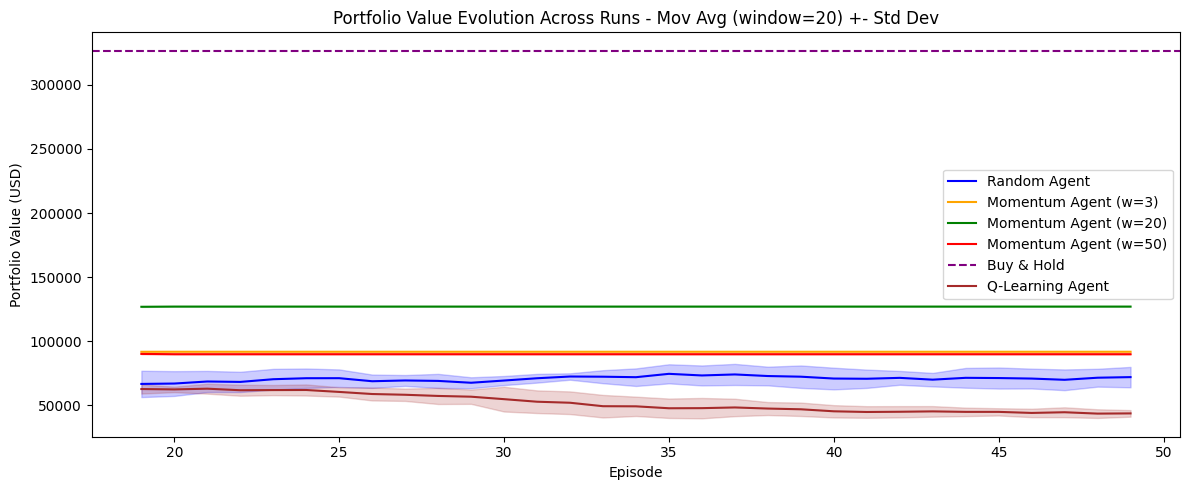

In [12]:
fig,ax = plt.subplots(figsize=(12, 5))
window = 20 # Moving average window for smoothing the plot, not the momentum agent's internal window
plot_value_evolution(compilation_random_agent, label='Random Agent', ax=ax, window=window, color='blue')
plot_value_evolution(compilation_momentum_agent_w3, label='Momentum Agent (w=3)', ax=ax, window=window, color='orange')
plot_value_evolution(compilation_momentum_agent_w20, label='Momentum Agent (w=20)', ax=ax, window=window, color='green')
plot_value_evolution(compilation_momentum_agent_w50, label='Momentum Agent (w=50)', ax=ax, window=window, color='red')
ax.axhline(buy_hold_value, color='purple', linestyle='--', label='Buy & Hold')
plot_value_evolution(compilation_qlearning_agent, label='Q-Learning Agent', ax=ax, window=window, color='brown')
ax.set_title(f'Portfolio Value Evolution Across Runs - Mov Avg (window={window}) +- Std Dev')
ax.set_xlabel('Episode')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## Tabela: configuração → melhor retorno → média/variância

In [16]:
import pandas as pd

def agent_summary(name, config, all_results):
    final_values = [run[-1] for run in all_results]  # last episode value per run
    return {
        'Agent': name,
        'Configuration': config,
        'Best Value': round(max(final_values), 2),
        'Std (final episode, across runs)': round(np.std(final_values), 2),
    }

rows = [
    agent_summary('Random', 'n/a', compilation_random_agent),
    agent_summary('Momentum', 'window=5', compilation_momentum_agent_w3),
    agent_summary('Momentum', 'window=20', compilation_momentum_agent_w20),
    agent_summary('Momentum', 'window=50', compilation_momentum_agent_w50),
    agent_summary('Buy & Hold', 'n/a', [[buy_hold_value]]),
    agent_summary('Q-Learning', 'alpha=0.1, gamma=0.9, epsilon=0.1', compilation_qlearning_agent)
]

summary_df = pd.DataFrame(rows)
summary_df

,Agent,Configuration,Best Value,"Std (final episode, across runs)"
0,Random,n/a,135202.98,37313.58
1,Momentum,window=5,91795.12,0.00
2,Momentum,window=20,127032.91,0.00
3,Momentum,window=50,89881.19,0.00
4,Buy & Hold,n/a,326657.42,0.00
5,Q-Learning,"alpha=0.1, gamma=0.9, epsilon=0.1",83308.57,24122.04
